# Sweep prediction summary analyzer

Loads the `sweep_predict_summary.csv` produced by any of the three sweep-predict scripts and answers the questions you'd actually run after a sweep:

1. **Top-N by prediction quality** (default `accuracy@iou0.50`) and by `val_loss_final`.
2. **Does training loss predict prediction quality?** Scatter of `val_loss_final` vs the primary prediction metric, colored by optimizer / scheduler.
3. **Per-IoU sweep** — how each model's primary metric degrades from IoU=0.3 → 0.5 → 0.7.
4. **Optimizer × scheduler grid** — heatmap of mean primary metric for each combo.
5. **LR sensitivity** — primary metric vs learning rate, grouped by optimizer.
6. **Per-IoU full-metric table** for the top-K runs (precision / recall / f1 / accuracy / PQ).

Edit the `CSV_PATH` / `PRIMARY_METRIC` / `PRIMARY_IOU` constants in the first config cell and Run-All.

In [25]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
# Point at whichever sweep you want to analyze.
#   StarDist:       unet_sweeps        →  scripts/model_prediction/stardist_sweeps/sweep_predict_summary.csv
#   U-Net:          unet_sweeps        →  scripts/model_prediction/unet_sweeps/sweep_predict_summary.csv
#   ROI → StarDist: stardist_roi_sweeps/sweep_predict_summary.csv
CSV_PATH = Path("stardist_sweeps/sweep_predict_summary.csv")

# What metric / IoU to treat as primary throughout the notebook.
# Anything ``matching_dataset`` returned at that IoU is available:
# precision / recall / f1 / accuracy / panoptic_quality /
# mean_matched_score / mean_true_score.
PRIMARY_METRIC = "accuracy"
PRIMARY_IOU = 0.5

TOP_K = 10  # used by every "top-K" table / plot below
IOUS = (0.3, 0.5, 0.7)
PRIMARY_COL = f"{PRIMARY_METRIC}@iou{PRIMARY_IOU:.2f}"

# Skip optimizers / schedulers / experiment-name substrings entirely
# (e.g. failed lr=10 runs you've already binned). Empty list = keep all.
SKIP_EXPERIMENT_SUBSTRINGS: list[str] = []

In [27]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f"{CSV_PATH} not found — point CSV_PATH at one of the three "
        f"sweep_predict_summary.csv outputs."
    )
df = pd.read_csv(CSV_PATH)
for sub in SKIP_EXPERIMENT_SUBSTRINGS:
    df = df[~df["experiment"].str.contains(sub, na=False)]

# Learning rate sometimes came in as a string like "1.0e-3" from the
# experiment-name tag parser; coerce to float so it sorts numerically.
if "learning_rate" in df.columns:
    df["learning_rate"] = pd.to_numeric(df["learning_rate"], errors="coerce")

if PRIMARY_COL not in df.columns:
    raise KeyError(
        f"{PRIMARY_COL} not in CSV columns — available metric columns: "
        + ", ".join(c for c in df.columns if "@iou" in c)
    )

print(f"Loaded {len(df)} rows from {CSV_PATH}")
print(f"Columns: {list(df.columns)}")
print()
print(f"Primary column: {PRIMARY_COL!r}")
print(f"  range: [{df[PRIMARY_COL].min():.4f}, {df[PRIMARY_COL].max():.4f}]  "
      f"non-null: {df[PRIMARY_COL].notna().sum()}/{len(df)}")
df.head()

Loaded 10 rows from stardist_sweeps/sweep_predict_summary.csv
Columns: ['experiment', 'optimizer', 'learning_rate', 'scheduler', 'val_loss_final', 'train_loss_final', 'epochs_done', 'mean_matched_score@iou0.70', 'accuracy@iou0.30', 'fn@iou0.30', 'mean_matched_score@iou0.50', 'mean_true_score@iou0.30', 'fp@iou0.70', 'mean_true_score@iou0.70', 'precision@iou0.50', 'panoptic_quality@iou0.70', 'fp@iou0.30', 'mean_matched_score@iou0.30', 'fn@iou0.70', 'f1@iou0.70', 'f1@iou0.30', 'precision@iou0.70', 'tp@iou0.70', 'fp@iou0.50', 'accuracy@iou0.70', 'accuracy@iou0.50', 'precision@iou0.30', 'mean_true_score@iou0.50', 'tp@iou0.50', 'tp@iou0.30', 'f1@iou0.50', 'recall@iou0.30', 'panoptic_quality@iou0.50', 'recall@iou0.70', 'panoptic_quality@iou0.30', 'recall@iou0.50', 'fn@iou0.50', 'n_inputs_scored']

Primary column: 'accuracy@iou0.50'
  range: [0.0011, 0.0079]  non-null: 10/10


,experiment,optimizer,learning_rate,scheduler,val_loss_final,train_loss_final,epochs_done,mean_matched_score@iou0.70,accuracy@iou0.30,fn@iou0.30,...,tp@iou0.50,tp@iou0.30,f1@iou0.50,recall@iou0.30,panoptic_quality@iou0.50,recall@iou0.70,panoptic_quality@iou0.30,recall@iou0.50,fn@iou0.50,n_inputs_scored
0,stardist_sweep_adam_lr1p0e-1_cosine,adam,0.100,cosine,0.299878,0.320169,99,0.806704,0.010008,256.0,...,10.0,24.0,0.008258,0.085714,0.005081,0.007143,0.009623,0.035714,270.0,1
1,stardist_sweep_adam_lr1p0e-1_noscheduler,adam,0.100,noscheduler,0.283319,0.289811,99,0.000000,0.005329,266.0,...,3.0,14.0,0.002272,0.050000,0.001289,0.000000,0.004393,0.010714,277.0,1
2,stardist_sweep_adam_lr1p0e-2_cosine,adam,0.010,cosine,0.239692,0.243647,99,0.782160,0.013381,239.0,...,19.0,41.0,0.012238,0.146429,0.007877,0.021429,0.013712,0.067857,261.0,1
3,stardist_sweep_adam_lr1p0e-2_noscheduler,adam,0.010,noscheduler,0.282613,0.241510,99,0.729699,0.011259,253.0,...,11.0,27.0,0.009072,0.096429,0.005418,0.007143,0.010607,0.039286,269.0,1
4,stardist_sweep_adam_lr1p0e-3_cosine,adam,0.001,cosine,0.255612,0.259293,99,0.788618,0.009709,248.0,...,11.0,32.0,0.006611,0.114286,0.004048,0.003571,0.008999,0.039286,269.0,1


## 1. Top-N rankings
Best by prediction quality (descending), best by training val_loss (ascending). The two often disagree — that's what the next cell visualises.

In [28]:
tag_cols = [c for c in ("experiment", "optimizer", "learning_rate", "scheduler") if c in df.columns]
metric_cols_at_primary = [
    c for c in df.columns if c.endswith(f"@iou{PRIMARY_IOU:.2f}") and c != PRIMARY_COL
]
train_cols = [c for c in ("val_loss_final", "train_loss_final", "epochs_done") if c in df.columns]

print(f"── Best by {PRIMARY_COL} (top {TOP_K}) ──")
best_pred = (
    df.dropna(subset=[PRIMARY_COL])
      .sort_values(PRIMARY_COL, ascending=False)
      .head(TOP_K)
)
display(best_pred[tag_cols + [PRIMARY_COL] + train_cols])

if "val_loss_final" in df.columns:
    print(f"\n── Best by val_loss_final ↓ (top {TOP_K}) ──")
    best_train = (
        df.dropna(subset=["val_loss_final"])
          .sort_values("val_loss_final")
          .head(TOP_K)
    )
    display(best_train[tag_cols + ["val_loss_final", PRIMARY_COL]])

── Best by accuracy@iou0.50 (top 10) ──


,experiment,optimizer,learning_rate,scheduler,accuracy@iou0.50,val_loss_final,train_loss_final,epochs_done
5,stardist_sweep_adam_lr1p0e-3_noscheduler,adam,0.001,noscheduler,0.007894,0.245388,0.246092,99
9,stardist_sweep_lars_lr1p0ep0_noscheduler,lars,NaN,noscheduler,0.006566,0.249292,0.234649,99
2,stardist_sweep_adam_lr1p0e-2_cosine,adam,0.010,cosine,0.006157,0.239692,0.243647,99
8,stardist_sweep_lars_lr1p0ep0_cosine,lars,NaN,cosine,0.004881,0.243139,0.235155,99
3,stardist_sweep_adam_lr1p0e-2_noscheduler,adam,0.010,noscheduler,0.004557,0.282613,0.241510,99
0,stardist_sweep_adam_lr1p0e-1_cosine,adam,0.100,cosine,0.004146,0.299878,0.320169,99
4,stardist_sweep_adam_lr1p0e-3_cosine,adam,0.001,cosine,0.003316,0.255612,0.259293,99
6,stardist_sweep_lars_lr1p0e-1_cosine,lars,0.100,cosine,0.002629,0.428545,0.435798,99
7,stardist_sweep_lars_lr1p0e-1_noscheduler,lars,0.100,noscheduler,0.002236,0.302469,0.309187,99
1,stardist_sweep_adam_lr1p0e-1_noscheduler,adam,0.100,noscheduler,0.001137,0.283319,0.289811,99



── Best by val_loss_final ↓ (top 10) ──


,experiment,optimizer,learning_rate,scheduler,val_loss_final,accuracy@iou0.50
2,stardist_sweep_adam_lr1p0e-2_cosine,adam,0.010,cosine,0.239692,0.006157
8,stardist_sweep_lars_lr1p0ep0_cosine,lars,NaN,cosine,0.243139,0.004881
5,stardist_sweep_adam_lr1p0e-3_noscheduler,adam,0.001,noscheduler,0.245388,0.007894
9,stardist_sweep_lars_lr1p0ep0_noscheduler,lars,NaN,noscheduler,0.249292,0.006566
4,stardist_sweep_adam_lr1p0e-3_cosine,adam,0.001,cosine,0.255612,0.003316
3,stardist_sweep_adam_lr1p0e-2_noscheduler,adam,0.010,noscheduler,0.282613,0.004557
1,stardist_sweep_adam_lr1p0e-1_noscheduler,adam,0.100,noscheduler,0.283319,0.001137
0,stardist_sweep_adam_lr1p0e-1_cosine,adam,0.100,cosine,0.299878,0.004146
7,stardist_sweep_lars_lr1p0e-1_noscheduler,lars,0.100,noscheduler,0.302469,0.002236
6,stardist_sweep_lars_lr1p0e-1_cosine,lars,0.100,cosine,0.428545,0.002629


## 2. Training loss vs prediction quality
If `val_loss_final` is well-correlated with the primary metric, the cheap-and-fast training proxy is reliable — you can trust it for early stopping. If the cloud is scattered, the prediction-quality sweep is the only honest source of truth.

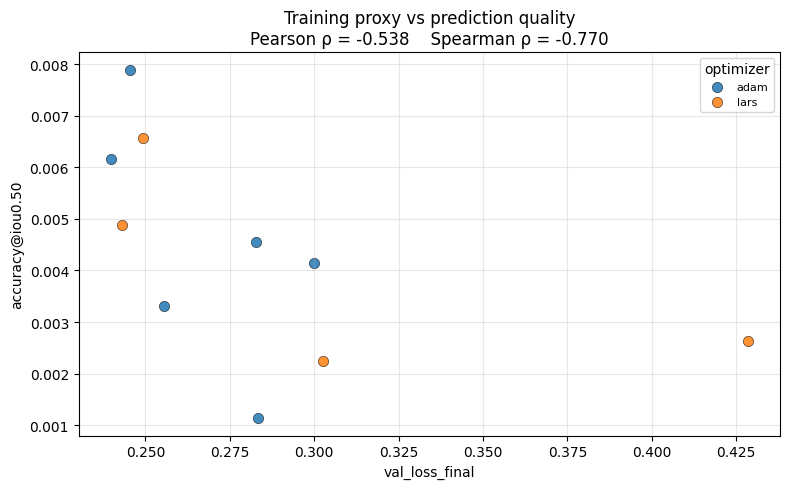

In [29]:
if "val_loss_final" not in df.columns:
    print("val_loss_final not in CSV — skipping correlation plot")
else:
    sub = df.dropna(subset=["val_loss_final", PRIMARY_COL])
    if sub.empty:
        print("No rows with both val_loss_final and primary metric — skipping")
    else:
        rho_p = sub["val_loss_final"].corr(sub[PRIMARY_COL], method="pearson")
        rho_s = sub["val_loss_final"].corr(sub[PRIMARY_COL], method="spearman")

        fig, ax = plt.subplots(figsize=(8, 5))
        opts = sorted(sub["optimizer"].dropna().unique().tolist()) if "optimizer" in sub.columns else [None]
        palette = plt.get_cmap("tab10").colors
        for i, opt in enumerate(opts):
            mask = sub["optimizer"] == opt if opt is not None else slice(None)
            ax.scatter(
                sub.loc[mask, "val_loss_final"],
                sub.loc[mask, PRIMARY_COL],
                color=palette[i % len(palette)],
                label=str(opt),
                s=55, alpha=0.85, edgecolors="black", linewidth=0.4,
            )
        ax.set_xlabel("val_loss_final")
        ax.set_ylabel(PRIMARY_COL)
        ax.set_title(
            f"Training proxy vs prediction quality\n"
            f"Pearson ρ = {rho_p:.3f}    Spearman ρ = {rho_s:.3f}"
        )
        ax.grid(True, alpha=0.3)
        if opts and opts[0] is not None:
            ax.legend(title="optimizer", loc="best", fontsize=8)
        fig.tight_layout()
        plt.show()

## 3. Per-IoU degradation
How sharply each model's primary metric falls as the IoU bar rises. A model that's `accuracy=0.7` at IoU=0.3 but `0.05` at IoU=0.7 has the right cells in roughly the right place but the boundaries are sloppy; flat curves = sharp boundaries.

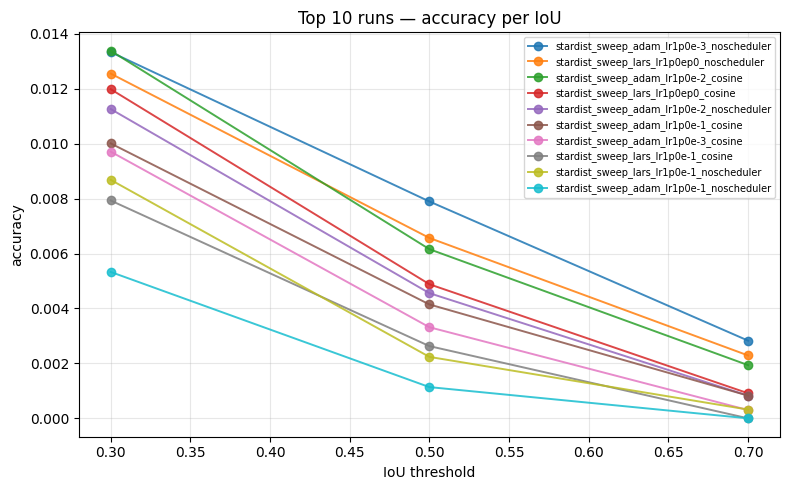

In [30]:
iou_cols = [f"{PRIMARY_METRIC}@iou{iou:.2f}" for iou in IOUS]
iou_cols_present = [c for c in iou_cols if c in df.columns]
if len(iou_cols_present) < 2:
    print(f"Need ≥ 2 IoU columns for the primary metric; found {iou_cols_present}")
else:
    # Plot top-K by PRIMARY_COL only — otherwise the chart is unreadable.
    top = (
        df.dropna(subset=[PRIMARY_COL])
          .sort_values(PRIMARY_COL, ascending=False)
          .head(TOP_K)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    xs = [float(c.split("@iou")[1]) for c in iou_cols_present]
    for _, row in top.iterrows():
        ys = [row[c] for c in iou_cols_present]
        ax.plot(xs, ys, marker="o", linewidth=1.4, alpha=0.85,
                label=row.get("experiment", "?"))
    ax.set_xlabel("IoU threshold")
    ax.set_ylabel(PRIMARY_METRIC)
    ax.set_title(f"Top {len(top)} runs — {PRIMARY_METRIC} per IoU")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, ncol=1)
    fig.tight_layout()
    plt.show()

## 6. Full per-IoU metric table for top-K runs
Wide view: every available metric × every available IoU for the top-K models by primary metric. Useful when you need to argue "this model has high accuracy but bad PQ" without scrolling through the raw CSV.

In [31]:
iou_metric_cols = [c for c in df.columns if re.match(r".+@iou\d\.\d{2}$", c)]
top = (
    df.dropna(subset=[PRIMARY_COL])
      .sort_values(PRIMARY_COL, ascending=False)
      .head(TOP_K)
)
display(top[tag_cols + train_cols + sorted(iou_metric_cols)])

,experiment,optimizer,learning_rate,scheduler,val_loss_final,train_loss_final,epochs_done,accuracy@iou0.30,accuracy@iou0.50,accuracy@iou0.70,...,panoptic_quality@iou0.70,precision@iou0.30,precision@iou0.50,precision@iou0.70,recall@iou0.30,recall@iou0.50,recall@iou0.70,tp@iou0.30,tp@iou0.50,tp@iou0.70
5,stardist_sweep_adam_lr1p0e-3_noscheduler,adam,0.001,noscheduler,0.245388,0.246092,99,0.013333,0.007894,0.002828,...,0.004503,0.014423,0.008585,0.003091,0.150000,0.089286,0.032143,42.0,25.0,9.0
9,stardist_sweep_lars_lr1p0ep0_noscheduler,lars,NaN,noscheduler,0.249292,0.234649,99,0.012550,0.006566,0.002288,...,0.003606,0.013640,0.007179,0.002513,0.135714,0.071429,0.025000,38.0,20.0,7.0
2,stardist_sweep_adam_lr1p0e-2_cosine,adam,0.010,cosine,0.239692,0.243647,99,0.013381,0.006157,0.001936,...,0.003023,0.014513,0.006726,0.002124,0.146429,0.067857,0.021429,41.0,19.0,6.0
8,stardist_sweep_lars_lr1p0ep0_cosine,lars,NaN,cosine,0.243139,0.235155,99,0.011982,0.004881,0.000912,...,0.001406,0.012940,0.005309,0.000995,0.139286,0.057143,0.010714,39.0,16.0,3.0
3,stardist_sweep_adam_lr1p0e-2_noscheduler,adam,0.010,noscheduler,0.282613,0.241510,99,0.011259,0.004557,0.000825,...,0.001204,0.012587,0.005128,0.000932,0.096429,0.039286,0.007143,27.0,11.0,2.0
0,stardist_sweep_adam_lr1p0e-1_cosine,adam,0.100,cosine,0.299878,0.320169,99,0.010008,0.004146,0.000826,...,0.001332,0.011204,0.004669,0.000934,0.085714,0.035714,0.007143,24.0,10.0,2.0
4,stardist_sweep_adam_lr1p0e-3_cosine,adam,0.001,cosine,0.255612,0.259293,99,0.009709,0.003316,0.000301,...,0.000474,0.010499,0.003609,0.000328,0.114286,0.039286,0.003571,32.0,11.0,1.0
6,stardist_sweep_lars_lr1p0e-1_cosine,lars,0.100,cosine,0.428545,0.435798,99,0.007930,0.002629,0.000000,...,0.000000,0.008566,0.002855,0.000000,0.096429,0.032143,0.000000,27.0,9.0,0.0
7,stardist_sweep_lars_lr1p0e-1_noscheduler,lars,0.100,noscheduler,0.302469,0.309187,99,0.008682,0.002236,0.000319,...,0.000518,0.009450,0.002450,0.000350,0.096429,0.025000,0.003571,27.0,7.0,1.0
1,stardist_sweep_adam_lr1p0e-1_noscheduler,adam,0.100,noscheduler,0.283319,0.289811,99,0.005329,0.001137,0.000000,...,0.000000,0.005930,0.001271,0.000000,0.050000,0.010714,0.000000,14.0,3.0,0.0
